In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial

PDK.activate()

## MMI 2X2 (VÉRTICES)

2026-06-04 09:05:43.711 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/2308182294.oas'


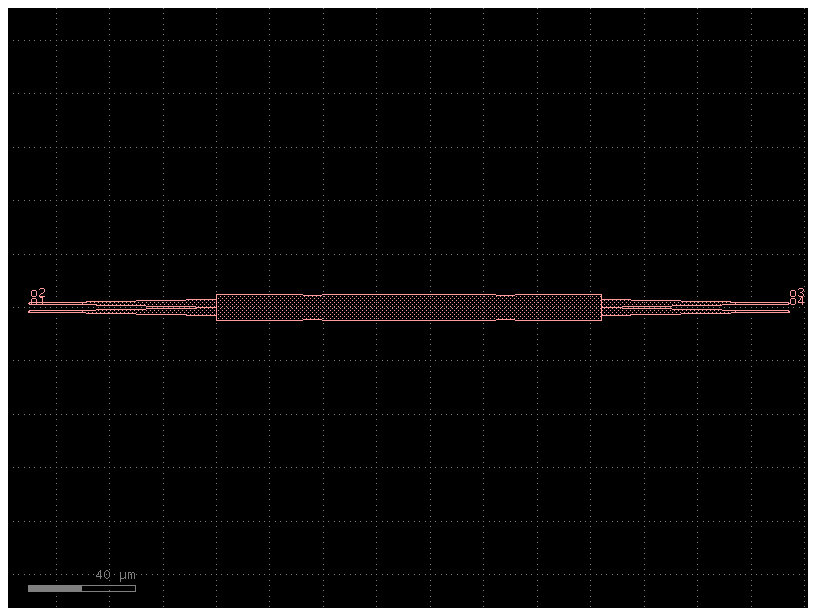

In [2]:
def b_symmetric_body_vertices(L_mmi, W_mmi, W_narrow):
    return np.array(
        [
            #body mmi
            # parte abajo: mirar dibujo libreta
            (0.0,          -W_mmi / 2), #p1
            (L_mmi / 4,    -W_narrow / 2), #p2
            (L_mmi / 2,    -W_mmi / 2), #p3
            (3*L_mmi / 4,  -W_narrow / 2),
            (L_mmi,        -W_mmi / 2),

            # parte arriba: mirar dibujo libreta
            (L_mmi,         W_mmi / 2), #p6
            (3*L_mmi / 4,   W_narrow / 2),
            (L_mmi / 2,     W_mmi / 2),
            (L_mmi / 4,     W_narrow / 2),
            (0.0,           W_mmi / 2),
        ]
    )

import numpy as np


# -------------------------
# TAPERS IZQUIERDA
# -------------------------

def taper_bottom_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, -W_mmi / 2 + d_io),
            (0.0, -W_mmi / 2 + d_io + Wt),

            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def taper_top_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, W_mmi / 2 - d_io - Wt),
            (0.0, W_mmi / 2 - d_io),

            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# TAPERS DERECHA
# -------------------------

def taper_bottom_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, -W_mmi / 2 + d_io),
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi, -W_mmi / 2 + d_io + Wt),
        ]
    )


def taper_top_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, W_mmi / 2 - d_io - Wt),
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi, W_mmi / 2 - d_io),
        ]
    )


# -------------------------
# GUÍAS IZQUIERDA
# -------------------------

def wg_bottom_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (-lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (-lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (-lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (-lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# GUÍAS DERECHA
# -------------------------

def wg_bottom_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )

def b_symmetric_mmi_vertices(
    L_mmi,
    W_mmi,
    W_narrow,
    L_wg,
    lt,
    wt,
    Wt,
    d_io,
):
    return {
        "mmi": b_symmetric_body_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            W_narrow=W_narrow,
        ),

        "in_bot_taper": taper_bottom_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_taper": taper_top_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_taper": taper_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_taper": taper_top_right_vertices(

            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_bot_wg": wg_bottom_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_wg": wg_top_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_wg": wg_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_wg": wg_top_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),
    }

L_mmi = 144
W_mmi = 10
W_narrow = 10-0.72
L_wg = 20
lt = 50
wt = 1.0
Wt = 3
d_io = 1.97

polys = b_symmetric_mmi_vertices(
    L_mmi=L_mmi,
    W_mmi=W_mmi,
    W_narrow=W_narrow,
    L_wg=L_wg,
    lt=lt,
    wt=wt,
    Wt=Wt,
    d_io=d_io,
)

mmi95 = gf.Component()
for poly in polys.values():
    mmi95.add_polygon(poly, layer="WG")

y_bot = -W_mmi / 2 + d_io + Wt / 2
y_top = W_mmi / 2 - d_io - Wt / 2

x_left = -lt - L_wg
x_right = L_mmi + lt + L_wg

mmi95.add_port(
    name="o1",
    center=(x_left, y_bot),
    width=wt,
    orientation=180,
    layer="WG",
)

mmi95.add_port(
    name="o2",
    center=(x_left, y_top),
    width=wt,
    orientation=180,
    layer="WG",
)

mmi95.add_port(
    name="o3",
    center=(x_right, y_top),
    width=wt,
    orientation=0,
    layer="WG",
)

mmi95.add_port(
    name="o4",
    center=(x_right, y_bot),
    width=wt,
    orientation=0,
    layer="WG",
)

mmi95.draw_ports()
mmi95.plot()
mmi95.show()

## MMI TEST STRUCTURES 2X2

2026-06-04 09:20:53.260 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/1007440263.oas'


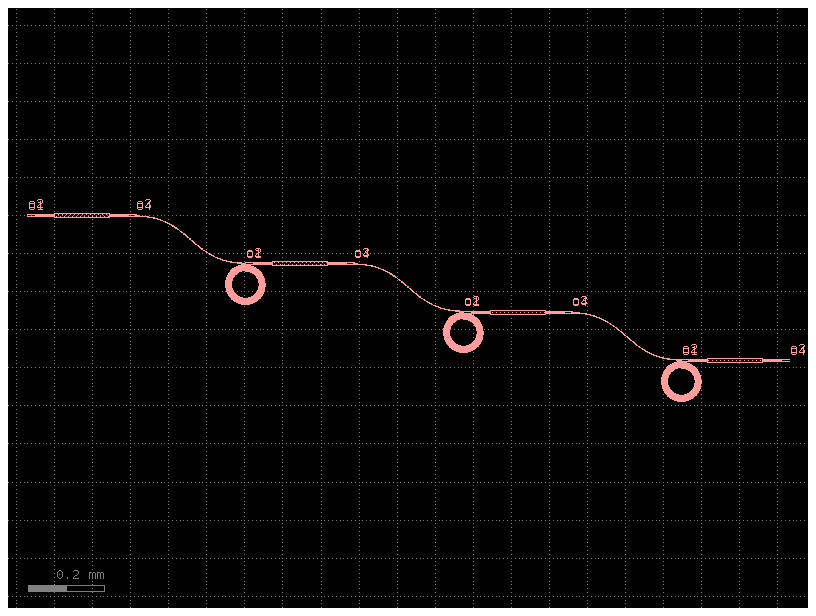

In [12]:
casc_A  = cells.mmi_ts(mmi95, 3000, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

2026-06-04 09:19:13.550 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/863658286.oas'


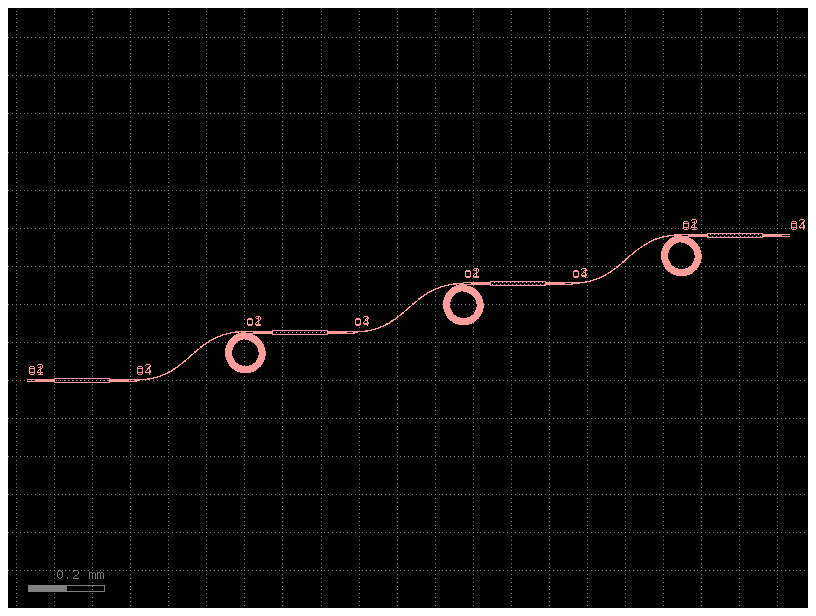

In [ ]:
casc_B  = cells.mmi_ts(mmi95, 3000, 500,  add_terminators=True)
casc_B.plot()
casc_B.show()